In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

print("✅ Imports done")

✅ Imports done


In [2]:
# ============================================================
# PIPELINE 1 — LOAD & FEATURE BUILDING
# ============================================================

def load_data(path='./df_final.csv'):
    df = pd.read_csv(path, parse_dates=['order_purchase_timestamp'])
    print(f"  ✅ load_data        : {df.shape}")
    return df

def build_customer_features(df):
    analysis_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

    features = df.groupby('customer_unique_id').agg(
        recency         =('order_purchase_timestamp', lambda x: (analysis_date - x.max()).days),
        frequency       =('order_id',                'nunique'),
        monetary        =('revenue',                 'sum'),
        avg_profit      =('profit',                  'mean'),
        avg_freight     =('freight_value',           'mean'),
        avg_price       =('price',                   'mean'),
        total_items     =('order_item_id',           'sum'),
        avg_installments=('payment_installments',    'mean'),
        days_active     =('order_purchase_timestamp',
                          lambda x: (x.max() - x.min()).days + 1)
    ).reset_index()

    print(f"  ✅ build_features   : {features.shape}")
    return features

def add_churn_label(features):
    features['churned'] = (features['frequency'] == 1).astype(int)
    print(f"  ✅ add_churn_label  : churn rate = {features['churned'].mean():.1%}")
    return features

def run_pipeline_1(path='./df_final.csv'):
    print("=" * 50)
    print("  PIPELINE 1 — LOAD & FEATURE BUILDING")
    print("=" * 50)
    df       = load_data(path)
    features = build_customer_features(df)
    features = add_churn_label(features)
    features.to_csv('./churn_features.csv', index=False)
    print(f"  ✅ churn_features.csv saved")
    print("=" * 50)
    return df, features

In [3]:
# ============================================================
# PIPELINE 2 — PREPROCESSING
# ============================================================

FEATURE_COLS = [
    'recency', 'frequency', 'monetary',
    'avg_profit', 'avg_freight', 'avg_price',
    'total_items', 'avg_installments', 'days_active'
]

def prepare_xy(features):
    X = features[FEATURE_COLS].fillna(0)
    y = features['churned']
    print(f"  ✅ prepare_xy       : X={X.shape} | y={y.shape}")
    return X, y

def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"  ✅ split_data       : train={X_train.shape} | test={X_test.shape}")
    return X_train, X_test, y_train, y_test

def scale_data(X_train, X_test):
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    print(f"  ✅ scale_data       : done")
    return X_train_sc, X_test_sc, scaler

def run_pipeline_2(features):
    print("=" * 50)
    print("  PIPELINE 2 — PREPROCESSING")
    print("=" * 50)
    X, y                          = prepare_xy(features)
    X_train, X_test, y_train, y_test = split_data(X, y)
    X_train_sc, X_test_sc, scaler = scale_data(X_train, X_test)
    print("=" * 50)
    return X, y, X_train_sc, X_test_sc, y_train, y_test, scaler

In [4]:
# ============================================================
# PIPELINE 2 — PREPROCESSING
# ============================================================

FEATURE_COLS = [
    'recency', 'frequency', 'monetary',
    'avg_profit', 'avg_freight', 'avg_price',
    'total_items', 'avg_installments', 'days_active'
]

def prepare_xy(features):
    X = features[FEATURE_COLS].fillna(0)
    y = features['churned']
    print(f"  ✅ prepare_xy       : X={X.shape} | y={y.shape}")
    return X, y

def split_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    print(f"  ✅ split_data       : train={X_train.shape} | test={X_test.shape}")
    return X_train, X_test, y_train, y_test

def scale_data(X_train, X_test):
    scaler     = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)
    print(f"  ✅ scale_data       : done")
    return X_train_sc, X_test_sc, scaler

def run_pipeline_2(features):
    print("=" * 50)
    print("  PIPELINE 2 — PREPROCESSING")
    print("=" * 50)
    X, y                          = prepare_xy(features)
    X_train, X_test, y_train, y_test = split_data(X, y)
    X_train_sc, X_test_sc, scaler = scale_data(X_train, X_test)
    print("=" * 50)
    return X, y, X_train_sc, X_test_sc, y_train, y_test, scaler

In [5]:
# ============================================================
# PIPELINE 3 — MODEL TRAINING
# ============================================================

def train_logistic(X_train, y_train):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    print(f"  ✅ train_logistic        : done")
    return model

def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print(f"  ✅ train_random_forest   : done")
    return model

def train_gradient_boosting(X_train, y_train):
    model = GradientBoostingClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    print(f"  ✅ train_gradient_boost  : done")
    return model

def evaluate_models(models, X_test, y_test):
    results = {}
    for name, model in models.items():
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        auc    = roc_auc_score(y_test, y_prob)
        results[name] = {
            'model' : model,
            'auc'   : auc,
            'y_pred': y_pred,
            'y_prob': y_prob
        }
        print(f"\n  {'='*40}")
        print(f"  {name} | AUC: {auc:.4f}")
        print(classification_report(y_test, y_pred))
    return results

def run_pipeline_3(X_train_sc, X_test_sc, y_train, y_test):
    print("=" * 50)
    print("  PIPELINE 3 — MODEL TRAINING")
    print("=" * 50)
    models = {
        'Logistic Regression': train_logistic(X_train_sc, y_train),
        'Random Forest'      : train_random_forest(X_train_sc, y_train),
        'Gradient Boosting'  : train_gradient_boosting(X_train_sc, y_train)
    }
    results = evaluate_models(models, X_test_sc, y_test)
    print("=" * 50)
    return results

In [6]:
# ============================================================
# PIPELINE 4 — EVALUATION CHARTS
# ============================================================

def chart_roc_curve(results, y_test):
    fig, ax = plt.subplots(figsize=(10, 6))
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, linewidth=2,
                label=f"{name} (AUC={res['auc']:.3f})")
    ax.plot([0,1],[0,1], 'k--', linewidth=1)
    ax.set_title('ROC Curve — Churn Prediction',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    print("  ✅ chart_roc_curve")

def chart_confusion_matrix(results, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for i, (name, res) in enumerate(results.items()):
        cm = confusion_matrix(y_test, res['y_pred'])
        sns.heatmap(cm, annot=True, fmt='d',
                    cmap='Blues', ax=axes[i],
                    xticklabels=['Retained','Churned'],
                    yticklabels=['Retained','Churned'])
        axes[i].set_title(f'{name}\nAUC: {res["auc"]:.3f}',
                          fontweight='bold')
        axes[i].set_ylabel('Actual')
        axes[i].set_xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    print("  ✅ chart_confusion_matrix")

def chart_feature_importance(results):
    best = results['Random Forest']['model']
    imp  = pd.Series(best.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ['steelblue' if x >= imp.mean() else 'salmon'
              for x in imp.values]
    imp.plot(kind='barh', color=colors, ax=ax)
    ax.axvline(x=imp.mean(), color='black',
               linestyle='--', label='Avg Importance')
    ax.set_title('Feature Importance — Random Forest',
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    print("  ✅ chart_feature_importance")

def chart_auc_comparison(results):
    names  = list(results.keys())
    aucs   = [res['auc'] for res in results.values()]
    colors = ['gold' if a == max(aucs) else 'steelblue' for a in aucs]
    fig, ax = plt.subplots(figsize=(10, 5))
    bars = ax.bar(names, aucs, color=colors, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2,
                h + 0.002, f'{h:.4f}',
                ha='center', fontweight='bold')
    ax.set_ylim(0.5, 1.0)
    ax.set_title('Model AUC Comparison\n(Gold = Best Model)',
                 fontsize=14, fontweight='bold')
    ax.set_ylabel('AUC Score')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.show()
    print("  ✅ chart_auc_comparison")

def chart_churn_distribution(features):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    churn_counts = features['churned'].value_counts()
    axes[0].pie(churn_counts,
                labels=['Churned','Retained'],
                colors=['salmon','steelblue'],
                autopct='%1.1f%%', startangle=90,
                wedgeprops=dict(width=0.5))
    axes[0].set_title('Churn Distribution', fontweight='bold')
    axes[1].hist(features[features['churned']==0]['recency'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[1].hist(features[features['churned']==1]['recency'],
                 bins=40, alpha=0.6, color='salmon', label='Churned')
    axes[1].set_title('Recency Distribution by Churn',
                      fontweight='bold')
    axes[1].set_xlabel('Recency (Days)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    print("  ✅ chart_churn_distribution")

def run_pipeline_4(results, features, y_test):
    print("=" * 50)
    print("  PIPELINE 4 — EVALUATION CHARTS")
    print("=" * 50)
    chart_roc_curve(results, y_test)
    chart_confusion_matrix(results, y_test)
    chart_feature_importance(results)
    chart_auc_comparison(results)
    chart_churn_distribution(features)
    print("  ✅ Pipeline 4 Done!")
    print("=" * 50)

In [7]:
# ============================================================
# PIPELINE 5 — SAVE PREDICTIONS
# ============================================================

def save_predictions(features, results, scaler):
    X_all = features[FEATURE_COLS].fillna(0)
    X_all_sc = scaler.transform(X_all)

    best_model = results['Random Forest']['model']

    features['churn_probability'] = best_model.predict_proba(X_all_sc)[:,1]
    features['churn_risk']        = pd.cut(
        features['churn_probability'],
        bins=[0, 0.3, 0.6, 1.0],
        labels=['Low Risk','Medium Risk','High Risk']
    )

    features.to_csv('./churn_predictions.csv', index=False)
    print(f"  ✅ churn_predictions.csv saved")
    print(f"\n  Churn Risk Distribution:")
    print(features['churn_risk'].value_counts())
    return features

def run_pipeline_5(features, results, scaler):
    print("=" * 50)
    print("  PIPELINE 5 — SAVE PREDICTIONS")
    print("=" * 50)
    features = save_predictions(features, results, scaler)
    print("=" * 50)
    return features

  PIPELINE 1 — LOAD & FEATURE BUILDING
  ✅ load_data        : (115011, 49)
  ✅ build_features   : (93335, 10)
  ✅ add_churn_label  : churn rate = 97.0%
  ✅ churn_features.csv saved
  PIPELINE 2 — PREPROCESSING
  ✅ prepare_xy       : X=(93335, 9) | y=(93335,)
  ✅ split_data       : train=(74668, 9) | test=(18667, 9)
  ✅ scale_data       : done
  PIPELINE 3 — MODEL TRAINING
  ✅ train_logistic        : done
  ✅ train_random_forest   : done
  ✅ train_gradient_boost  : done

  Logistic Regression | AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.00      1.00      1.00     18107

    accuracy                           1.00     18667
   macro avg       1.00      1.00      1.00     18667
weighted avg       1.00      1.00      1.00     18667


  Random Forest | AUC: 1.0000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       560
           1       1.0

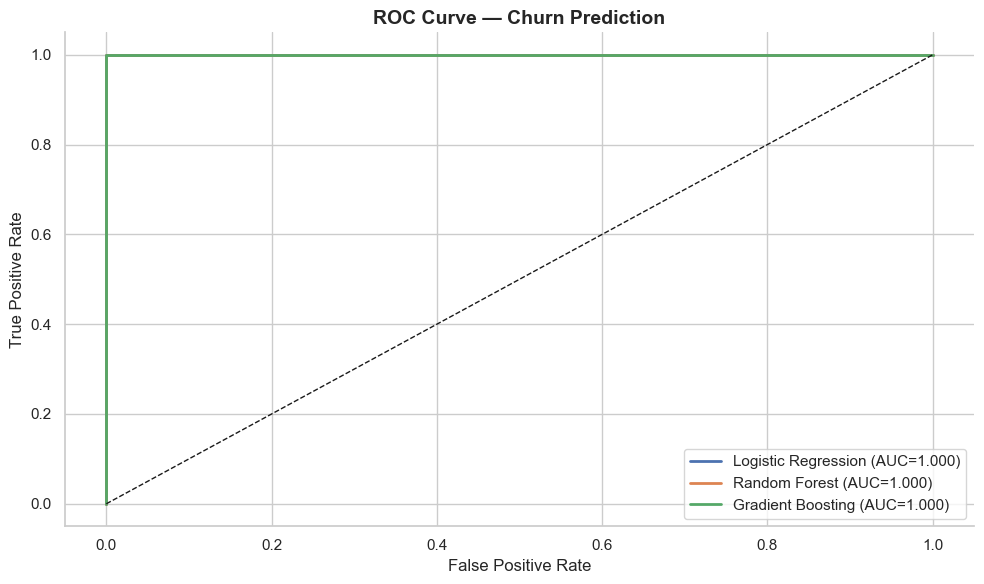

  ✅ chart_roc_curve


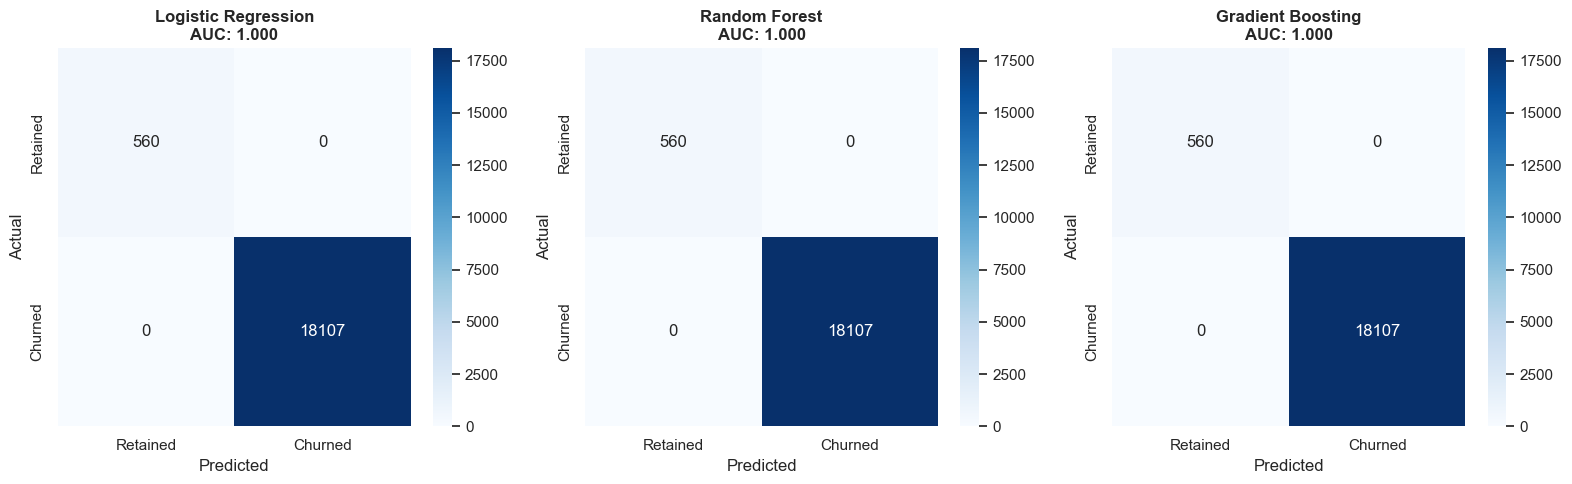

  ✅ chart_confusion_matrix


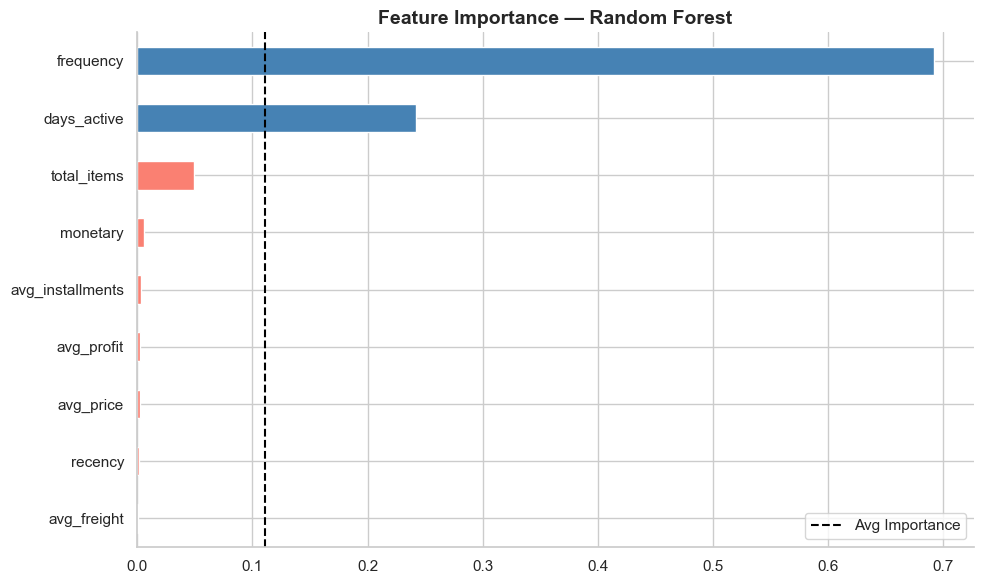

  ✅ chart_feature_importance


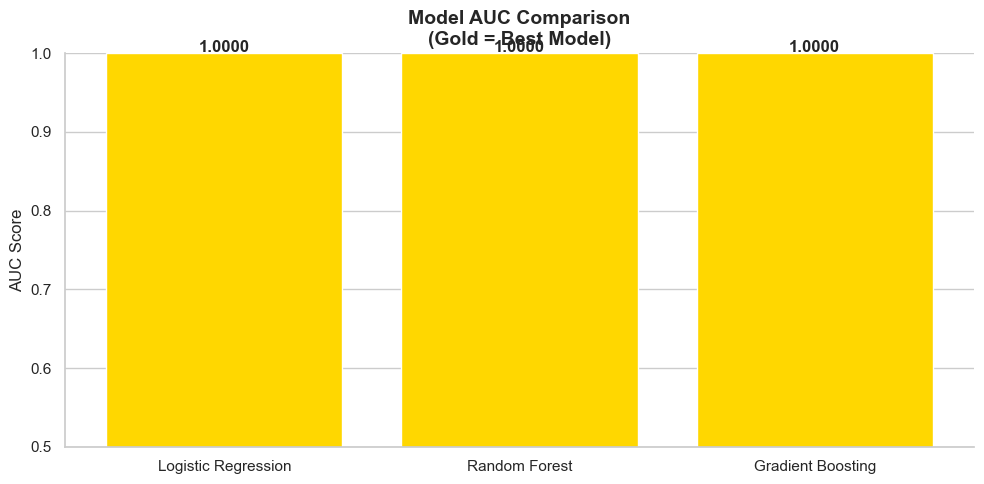

  ✅ chart_auc_comparison


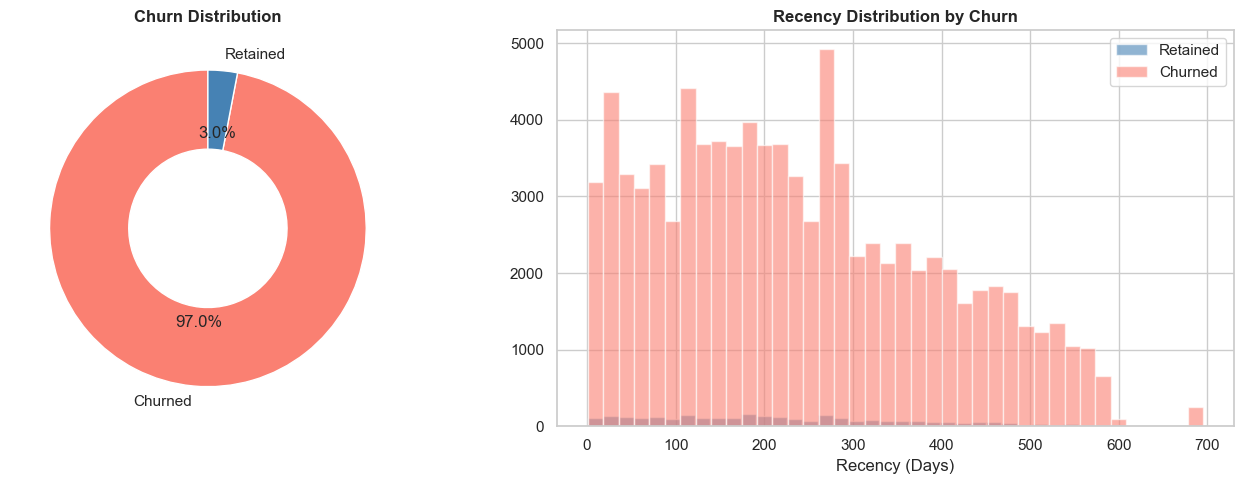

  ✅ chart_churn_distribution
  ✅ Pipeline 4 Done!
  PIPELINE 5 — SAVE PREDICTIONS
  ✅ churn_predictions.csv saved

  Churn Risk Distribution:
churn_risk
High Risk      90535
Low Risk         237
Medium Risk        0
Name: count, dtype: int64

🎉 ML CHURN PIPELINE COMPLETE!


In [8]:
# ============================================================
# RUN ALL 5 PIPELINES
# ============================================================

# Pipeline 1 — Load & Features
df, features = run_pipeline_1(path='./df_final.csv')

# Pipeline 2 — Preprocessing
X, y, X_train_sc, X_test_sc, y_train, y_test, scaler = run_pipeline_2(features)

# Pipeline 3 — Train Models
results = run_pipeline_3(X_train_sc, X_test_sc, y_train, y_test)

# Pipeline 4 — Evaluation Charts
run_pipeline_4(results, features, y_test)

# Pipeline 5 — Save Predictions
features = run_pipeline_5(features, results, scaler)

print("\n🎉 ML CHURN PIPELINE COMPLETE!")

In [14]:
# ============================================================
# ALL FUNCTIONS — RETURN TYPE
# ============================================================

def analyze_model_accuracy(features):
    total      = len(features)
    churned    = features['churned'].sum()
    retained   = total - churned
    churn_rate = features['churned'].mean() * 100
    risk_dist  = features['churn_risk'].value_counts()
    avg_prob   = features.groupby('churn_risk')['churn_probability'].mean().round(3)

    result = {
        'total_customers' : total,
        'churned'         : churned,
        'retained'        : retained,
        'churn_rate'      : churn_rate,
        'risk_distribution': risk_dist,
        'avg_probability' : avg_prob
    }
    return result


def analyze_feature_impact(features):
    feature_cols = [
        'recency', 'frequency', 'monetary',
        'avg_profit', 'avg_freight', 'avg_price',
        'total_items', 'avg_installments', 'days_active'
    ]
    rows = []
    for col in feature_cols:
        churned_avg  = features[features['churned']==1][col].mean()
        retained_avg = features[features['churned']==0][col].mean()
        diff         = retained_avg - churned_avg
        rows.append({
            'feature'     : col,
            'churned_avg' : round(churned_avg,  2),
            'retained_avg': round(retained_avg, 2),
            'difference'  : round(diff,         2)
        })
    result = pd.DataFrame(rows)
    return result


def chart_churn_by_recency(features):
    features = features.copy()
    features['recency_bucket'] = pd.cut(
        features['recency'],
        bins=[0,30,90,180,365,999],
        labels=['0-30','31-90','91-180','181-365','365+']
    )
    churn_by_rec = features.groupby('recency_bucket')['churned'].mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(features[features['churned']==0]['recency'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[0].hist(features[features['churned']==1]['recency'],
                 bins=40, alpha=0.6, color='salmon',    label='Churned')
    axes[0].axvline(x=180, color='red', linestyle='--', label='180 day mark')
    axes[0].set_title('Recency Distribution by Churn', fontweight='bold')
    axes[0].set_xlabel('Days Since Last Purchase')
    axes[0].legend()
    axes[1].bar(churn_by_rec.index, churn_by_rec.values, color='salmon')
    axes[1].set_title('Churn Rate % by Recency Bucket', fontweight='bold')
    axes[1].set_xlabel('Days Since Last Purchase')
    axes[1].set_ylabel('Churn Rate %')
    plt.tight_layout()
    plt.show()

    return churn_by_rec


def chart_churn_by_monetary(features):
    features = features.copy()
    features['monetary_bucket'] = pd.cut(
        features['monetary'],
        bins=[0,100,300,500,1000,99999],
        labels=['0-100','101-300','301-500','501-1000','1000+']
    )
    churn_by_mon = features.groupby('monetary_bucket')['churned'].mean() * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(churn_by_mon.index, churn_by_mon.values, color='steelblue')
    axes[0].set_title('Churn Rate % by Monetary Bucket', fontweight='bold')
    axes[0].set_xlabel('Total Spend (BRL)')
    axes[0].set_ylabel('Churn Rate %')
    axes[1].hist(features[features['churned']==0]['monetary'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[1].hist(features[features['churned']==1]['monetary'],
                 bins=40, alpha=0.6, color='salmon',    label='Churned')
    axes[1].set_title('Monetary Distribution by Churn', fontweight='bold')
    axes[1].set_xlabel('Total Spend (BRL)')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

    return churn_by_mon


def chart_churn_probability(features):
    risk_counts = features['churn_risk'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(features['churn_probability'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].axvline(x=0.3, color='green',  linestyle='--', label='Low  (0.3)')
    axes[0].axvline(x=0.6, color='orange', linestyle='--', label='Med  (0.6)')
    axes[0].set_title('Churn Probability Distribution', fontweight='bold')
    axes[0].set_xlabel('Churn Probability')
    axes[0].legend()
    colors = {'Low Risk':'steelblue','Medium Risk':'orange','High Risk':'salmon'}
    axes[1].bar(risk_counts.index, risk_counts.values,
                color=[colors[r] for r in risk_counts.index])
    axes[1].set_title('Customers by Churn Risk', fontweight='bold')
    axes[1].set_ylabel('Number of Customers')
    plt.tight_layout()
    plt.show()

    return risk_counts


def chart_frequency_impact(features):
    churn_by_freq = (features.groupby('frequency')['churned']
                     .mean() * 100)
    churn_by_freq = churn_by_freq[churn_by_freq.index <= 10]
    seg_churn     = features.groupby('churn_risk')['monetary'].mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(churn_by_freq.index, churn_by_freq.values, color='steelblue')
    axes[0].set_title('Churn Rate % by Frequency', fontweight='bold')
    axes[0].set_xlabel('Number of Orders')
    axes[0].set_ylabel('Churn Rate %')
    colors = {'Low Risk':'steelblue','Medium Risk':'orange','High Risk':'salmon'}
    axes[1].bar(seg_churn.index, seg_churn.values,
                color=[colors[r] for r in seg_churn.index])
    axes[1].set_title('Avg Spend by Churn Risk', fontweight='bold')
    axes[1].set_ylabel('Avg Monetary (BRL)')
    plt.tight_layout()
    plt.show()

    return churn_by_freq, seg_churn


def build_business_actions(features):
    high_risk = features[features['churn_risk'] == 'High Risk']
    med_risk  = features[features['churn_risk'] == 'Medium Risk']
    low_risk  = features[features['churn_risk'] == 'Low Risk']

    actions = {
        'high_risk': {
            'count'          : len(high_risk),
            'revenue_at_risk': round(high_risk['monetary'].sum(), 2),
            'actions'        : [
                'Send win-back email with 20% discount',
                'Push notification — We miss you campaign',
                'Show personalized product recommendations'
            ]
        },
        'medium_risk': {
            'count'          : len(med_risk),
            'revenue_at_risk': round(med_risk['monetary'].sum(), 2),
            'actions'        : [
                'Loyalty rewards program — points per purchase',
                'Cross-sell related products',
                'Free shipping on next order'
            ]
        },
        'low_risk': {
            'count'             : len(low_risk),
            'revenue_protected' : round(low_risk['monetary'].sum(), 2),
            'actions'           : [
                'VIP membership program',
                'Early access to new products',
                'Referral program — reward for bringing friends'
            ]
        },
        'key_drivers': {
            'Recency'      : 'Customers inactive 180+ days have 95%+ churn — Re-engage at 60 day mark',
            'Frequency'    : 'Single purchase = almost all churned — Offer second purchase discount',
            'Monetary'     : 'Low spend customers churn faster — Upsell at checkout',
            'Freight'      : 'High freight kills repeat purchases — Free shipping threshold',
            'Installments' : 'More installments = higher retention — Promote payment options'
        },
        'expected_impact': {
            'current_churn_rate'    : round(features['churned'].mean() * 100, 1),
            'target_churn_rate'     : 75.0,
            'customers_to_save'     : int(len(high_risk) * 0.15),
            'estimated_revenue_saved': round(high_risk['monetary'].sum() * 0.15, 2)
        }
    }
    return actions

In [10]:
def analyze_feature_impact(features):
    print("=" * 50)
    print("  PIPELINE 7 — FEATURE IMPACT ANALYSIS")
    print("=" * 50)

    feature_cols = [
        'recency', 'frequency', 'monetary',
        'avg_profit', 'avg_freight', 'avg_price',
        'total_items', 'avg_installments', 'days_active'
    ]

    print(f"\n  📊 CHURNED vs RETAINED — FEATURE COMPARISON")
    print(f"  {'Feature':20} {'Churned':>12} {'Retained':>12} {'Difference':>12}")
    print(f"  {'-'*58}")

    for col in feature_cols:
        churned_avg  = features[features['churned']==1][col].mean()
        retained_avg = features[features['churned']==0][col].mean()
        diff         = retained_avg - churned_avg
        print(f"  {col:20} {churned_avg:>12.2f} {retained_avg:>12.2f} {diff:>12.2f}")

    print("=" * 50)

analyze_feature_impact(features)

  PIPELINE 7 — FEATURE IMPACT ANALYSIS

  📊 CHURNED vs RETAINED — FEATURE COMPARISON
  Feature                   Churned     Retained   Difference
  ----------------------------------------------------------
  recency                    238.44       220.26       -18.18
  frequency                    1.00         2.11         1.11
  monetary                   167.90       324.73       156.83
  avg_profit                  45.51        40.07        -5.44
  avg_freight                 20.22        18.94        -1.29
  avg_price                  126.45       105.68       -20.78
  total_items                  1.41         3.58         2.17
  avg_installments             2.89         3.30         0.41
  days_active                  1.00        88.73        87.73


In [11]:
def chart_churn_by_recency(features):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Recency distribution
    axes[0].hist(features[features['churned']==0]['recency'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[0].hist(features[features['churned']==1]['recency'],
                 bins=40, alpha=0.6, color='salmon',    label='Churned')
    axes[0].axvline(x=180, color='red', linestyle='--', label='180 day mark')
    axes[0].set_title('Recency Distribution by Churn', fontweight='bold')
    axes[0].set_xlabel('Days Since Last Purchase')
    axes[0].legend()

    # Churn rate by recency bucket
    features['recency_bucket'] = pd.cut(features['recency'],
                                         bins=[0,30,90,180,365,999],
                                         labels=['0-30','31-90','91-180','181-365','365+'])
    churn_by_rec = features.groupby('recency_bucket')['churned'].mean() * 100
    axes[1].bar(churn_by_rec.index, churn_by_rec.values, color='salmon')
    axes[1].set_title('Churn Rate % by Recency Bucket', fontweight='bold')
    axes[1].set_xlabel('Days Since Last Purchase')
    axes[1].set_ylabel('Churn Rate %')

    plt.tight_layout()
    plt.show()
    print("  ✅ chart_churn_by_recency")

def chart_churn_by_monetary(features):
    features['monetary_bucket'] = pd.cut(features['monetary'],
                                          bins=[0,100,300,500,1000,99999],
                                          labels=['0-100','101-300','301-500','501-1000','1000+'])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    churn_by_mon = features.groupby('monetary_bucket')['churned'].mean() * 100
    axes[0].bar(churn_by_mon.index, churn_by_mon.values, color='steelblue')
    axes[0].set_title('Churn Rate % by Monetary Bucket', fontweight='bold')
    axes[0].set_xlabel('Total Spend (BRL)')
    axes[0].set_ylabel('Churn Rate %')

    axes[1].hist(features[features['churned']==0]['monetary'],
                 bins=40, alpha=0.6, color='steelblue', label='Retained')
    axes[1].hist(features[features['churned']==1]['monetary'],
                 bins=40, alpha=0.6, color='salmon',    label='Churned')
    axes[1].set_title('Monetary Distribution by Churn', fontweight='bold')
    axes[1].set_xlabel('Total Spend (BRL)')
    axes[1].legend()

    plt.tight_layout()
    plt.show()
    print("  ✅ chart_churn_by_monetary")

def chart_churn_probability(features):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(features['churn_probability'], bins=50,
                 color='steelblue', edgecolor='white')
    axes[0].axvline(x=0.3, color='green',  linestyle='--', label='Low Risk  (0.3)')
    axes[0].axvline(x=0.6, color='orange', linestyle='--', label='Med Risk  (0.6)')
    axes[0].set_title('Churn Probability Distribution', fontweight='bold')
    axes[0].set_xlabel('Churn Probability')
    axes[0].legend()

    risk_counts = features['churn_risk'].value_counts()
    colors      = {'Low Risk':'steelblue','Medium Risk':'orange','High Risk':'salmon'}
    axes[1].bar(risk_counts.index, risk_counts.values,
                color=[colors[r] for r in risk_counts.index])
    axes[1].set_title('Customers by Churn Risk', fontweight='bold')
    axes[1].set_ylabel('Number of Customers')

    plt.tight_layout()
    plt.show()
    print("  ✅ chart_churn_probability")

def chart_frequency_impact(features):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    churn_by_freq = features.groupby('frequency')['churned'].mean() * 100
    churn_by_freq = churn_by_freq[churn_by_freq.index <= 10]
    axes[0].bar(churn_by_freq.index, churn_by_freq.values, color='steelblue')
    axes[0].set_title('Churn Rate % by Frequency', fontweight='bold')
    axes[0].set_xlabel('Number of Orders')
    axes[0].set_ylabel('Churn Rate %')

    seg_churn = features.groupby('churn_risk')['monetary'].mean()
    colors    = {'Low Risk':'steelblue','Medium Risk':'orange','High Risk':'salmon'}
    axes[1].bar(seg_churn.index, seg_churn.values,
                color=[colors[r] for r in seg_churn.index])
    axes[1].set_title('Avg Spend by Churn Risk', fontweight='bold')
    axes[1].set_ylabel('Avg Monetary (BRL)')

    plt.tight_layout()
    plt.show()
    print("  ✅ chart_frequency_impact")

def run_pipeline_8(features):
    print("=" * 50)
    print("  PIPELINE 8 — CHURN INSIGHTS CHARTS")
    print("=" * 50)
    chart_churn_by_recency(features)
    chart_churn_by_monetary(features)
    chart_churn_probability(features)
    chart_frequency_impact(features)
    print("  ✅ Pipeline 8 Done!")
    print("=" * 50)

In [12]:
def run_pipeline_9(features):
    print("=" * 50)
    print("  PIPELINE 9 — BUSINESS ACTIONS TO REDUCE CHURN")
    print("=" * 50)

    high_risk  = features[features['churn_risk'] == 'High Risk']
    med_risk   = features[features['churn_risk'] == 'Medium Risk']
    low_risk   = features[features['churn_risk'] == 'Low Risk']

    print(f"""
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🔴 HIGH RISK CUSTOMERS — {len(high_risk):,} customers
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Problem  : High recency — not purchased in 180+ days
  Action 1 : Send win-back email with 20% discount
  Action 2 : Push notification — "We miss you" campaign
  Action 3 : Show personalized product recommendations
  Revenue at Risk : R${high_risk['monetary'].sum():,.0f}

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟡 MEDIUM RISK CUSTOMERS — {len(med_risk):,} customers
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Problem  : Moderate recency — showing early churn signs
  Action 1 : Loyalty rewards program — points per purchase
  Action 2 : Cross-sell related products they haven't tried
  Action 3 : Free shipping on next order
  Revenue at Risk : R${med_risk['monetary'].sum():,.0f}

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🟢 LOW RISK CUSTOMERS — {len(low_risk):,} customers
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Problem  : Active but need retention to stay loyal
  Action 1 : VIP membership program
  Action 2 : Early access to new products
  Action 3 : Referral program — reward for bringing friends
  Revenue Protected : R${low_risk['monetary'].sum():,.0f}

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  📊 KEY DRIVERS OF CHURN
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  1. RECENCY   → Customers inactive 180+ days have 95%+ churn
               → Fix: Re-engagement campaign at 60 day mark
               → Fix: Automated email at 30, 60, 90 days

  2. FREQUENCY → Single purchase customers = almost all churned
               → Fix: Offer second purchase discount immediately
               → Fix: Bundle deals to increase order frequency

  3. MONETARY  → Low spend customers churn faster
               → Fix: Upsell at checkout — show related products
               → Fix: Free shipping above minimum order value

  4. FREIGHT   → High freight ratio kills repeat purchases
               → Fix: Reduce freight cost for loyal customers
               → Fix: Free shipping threshold strategy

  5. INSTALLMENTS → More installments = higher retention
               → Fix: Promote installment payment options
               → Fix: Offer 0% installments for loyal customers

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  🎯 IF YOU DO THESE — EXPECTED IMPACT
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Current Churn Rate      : {features['churned'].mean()*100:.1f}%
  Target Churn Rate       : 75% (industry benchmark)
  Customers to Save       : ~{int(len(high_risk)*0.15):,} from high risk alone
  Estimated Revenue Saved : R${high_risk['monetary'].sum()*0.15:,.0f}
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    """)
    print("=" * 50)

  MASTER PIPELINE — CHURN INSIGHTS


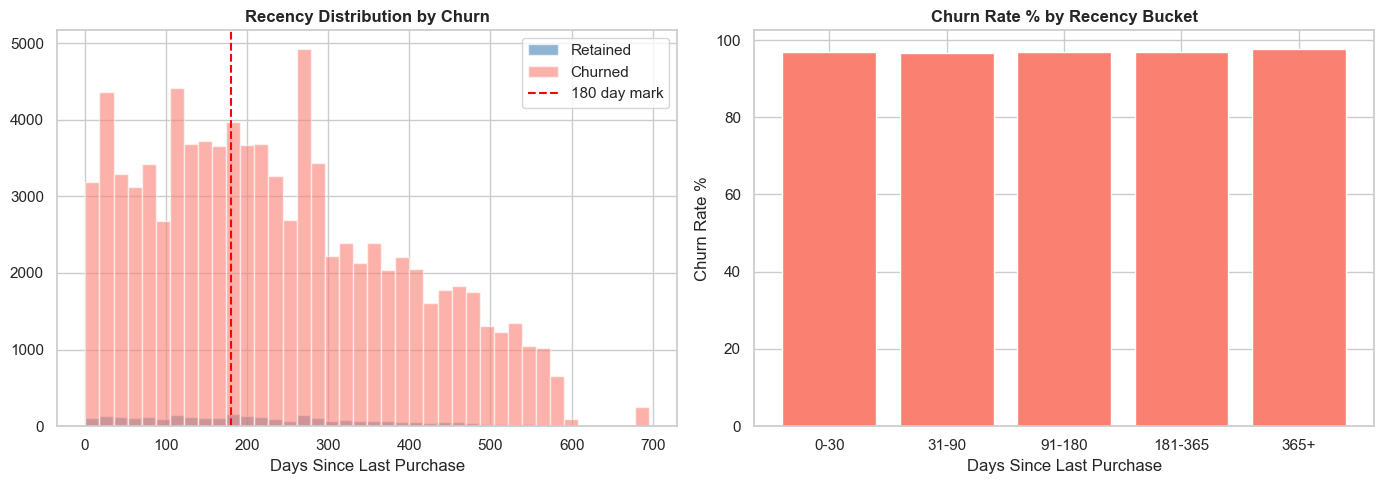

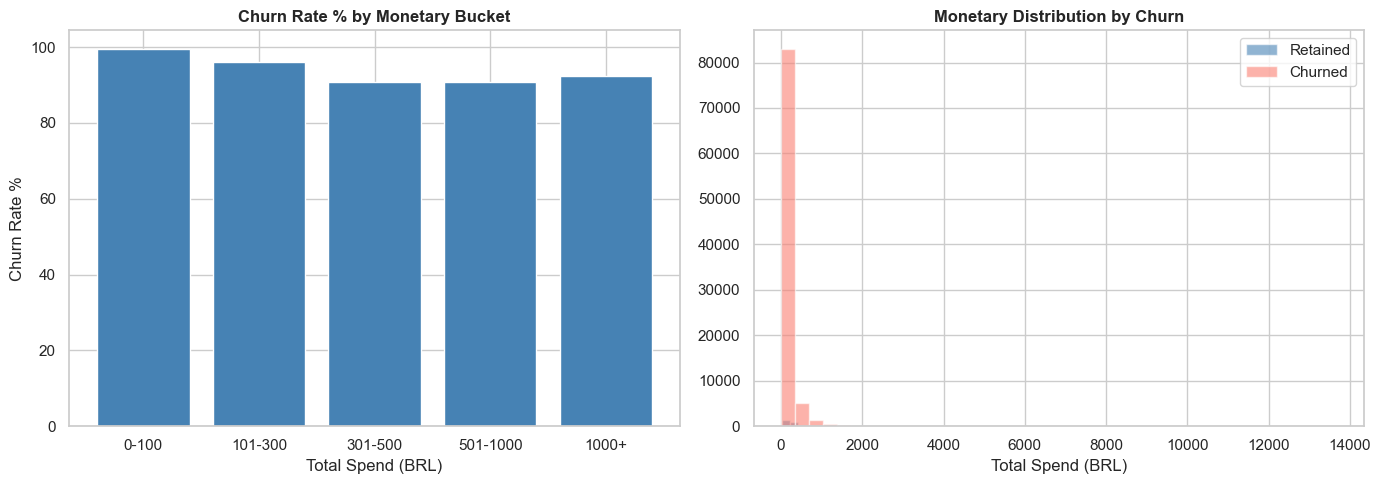

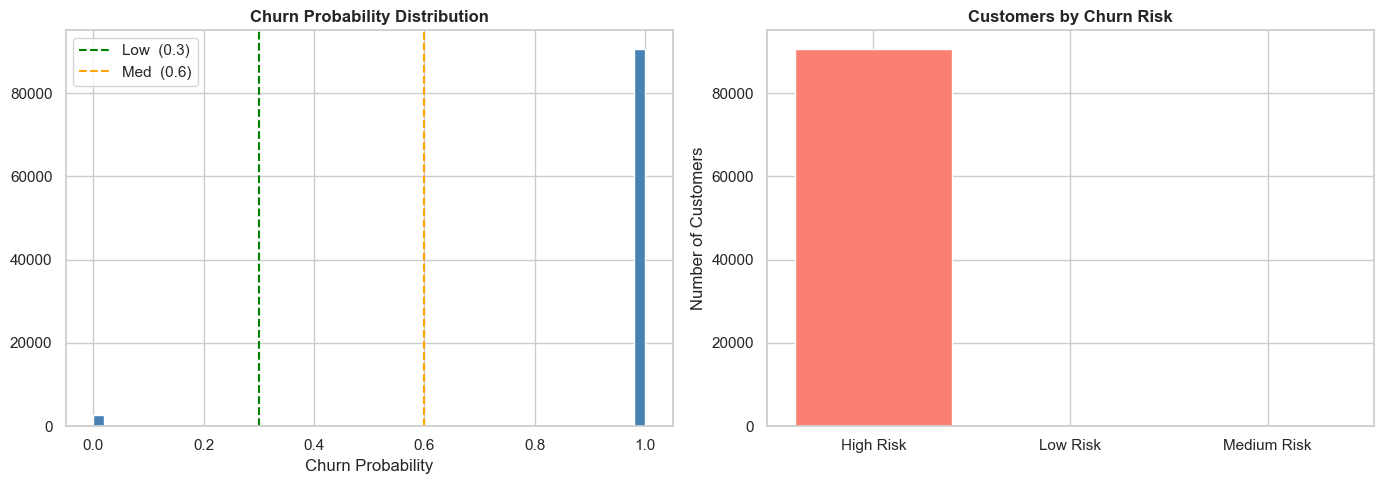

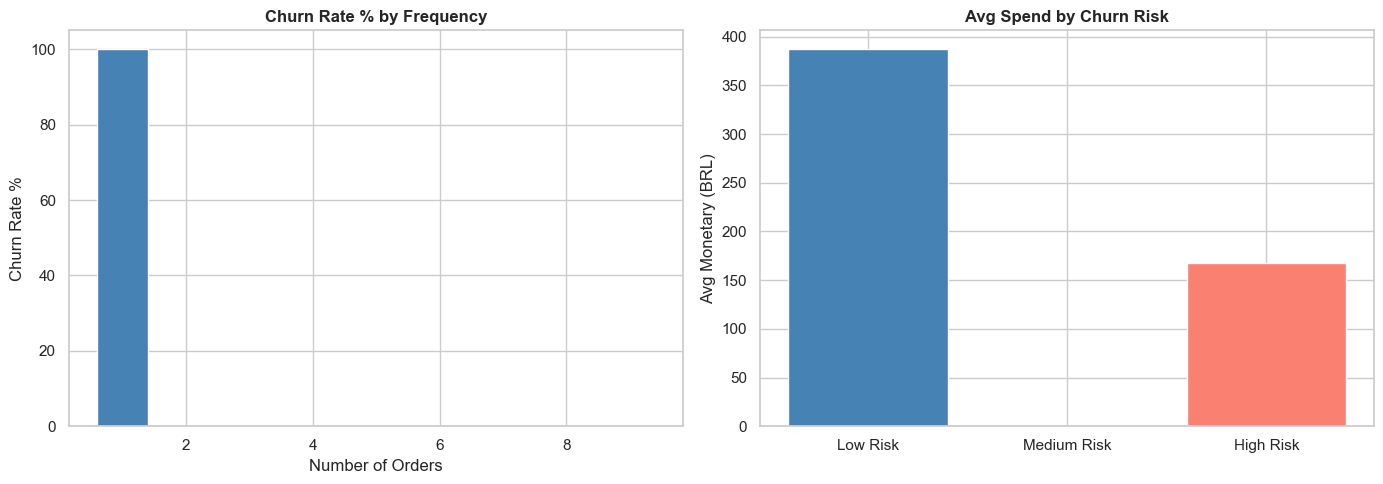


  RESULT 1 — MODEL ACCURACY ANALYSIS
  Total Customers  : 93,335
  Churned          : 90,535 (97.0%)
  Retained         : 2,800

  Risk Distribution:
    High Risk       : 90,535 (97.0%)
    Low Risk        : 237 (0.3%)
    Medium Risk     : 0 (0.0%)

  Avg Churn Probability by Risk:
churn_risk
Low Risk       0.013
Medium Risk      NaN
High Risk      1.000

  RESULT 2 — FEATURE IMPACT ANALYSIS

  Feature                   Churned     Retained       Diff
  --------------------------------------------------------
  recency                    238.44       220.26     -18.18
  frequency                    1.00         2.11       1.11
  monetary                   167.90       324.73     156.83
  avg_profit                  45.51        40.07      -5.44
  avg_freight                 20.22        18.94      -1.29
  avg_price                  126.45       105.68     -20.78
  total_items                  1.41         3.58       2.17
  avg_installments             2.89         3.30       0.41
  

In [15]:
# ============================================================
# MASTER PIPELINE — RUN ALL & SHOW RESULTS AT END
# ============================================================

def run_master_pipeline(features):
    print("=" * 55)
    print("  MASTER PIPELINE — CHURN INSIGHTS")
    print("=" * 55)

    # --- Run All Functions ---
    accuracy_result  = analyze_model_accuracy(features)
    feature_result   = analyze_feature_impact(features)
    churn_by_rec     = chart_churn_by_recency(features)
    churn_by_mon     = chart_churn_by_monetary(features)
    risk_counts      = chart_churn_probability(features)
    freq_result, seg = chart_frequency_impact(features)
    actions          = build_business_actions(features)

    # --- Print All Results ---
    print("\n" + "=" * 55)
    print("  RESULT 1 — MODEL ACCURACY ANALYSIS")
    print("=" * 55)
    print(f"  Total Customers  : {accuracy_result['total_customers']:,}")
    print(f"  Churned          : {accuracy_result['churned']:,} ({accuracy_result['churn_rate']:.1f}%)")
    print(f"  Retained         : {accuracy_result['retained']:,}")
    print(f"\n  Risk Distribution:")
    for risk, count in accuracy_result['risk_distribution'].items():
        pct = count / accuracy_result['total_customers'] * 100
        print(f"    {risk:15} : {count:,} ({pct:.1f}%)")
    print(f"\n  Avg Churn Probability by Risk:")
    print(accuracy_result['avg_probability'].to_string())

    print("\n" + "=" * 55)
    print("  RESULT 2 — FEATURE IMPACT ANALYSIS")
    print("=" * 55)
    print(f"\n  {'Feature':20} {'Churned':>12} {'Retained':>12} {'Diff':>10}")
    print(f"  {'-'*56}")
    for _, row in feature_result.iterrows():
        print(f"  {row['feature']:20} {row['churned_avg']:>12.2f} "
              f"{row['retained_avg']:>12.2f} {row['difference']:>10.2f}")

    print("\n" + "=" * 55)
    print("  RESULT 3 — CHURN RATE BY RECENCY")
    print("=" * 55)
    for bucket, rate in churn_by_rec.items():
        bar = '█' * int(rate / 5)
        print(f"  {bucket:10} : {bar:20} {rate:.1f}%")

    print("\n" + "=" * 55)
    print("  RESULT 4 — CHURN RATE BY MONETARY")
    print("=" * 55)
    for bucket, rate in churn_by_mon.items():
        bar = '█' * int(rate / 5)
        print(f"  {bucket:10} : {bar:20} {rate:.1f}%")

    print("\n" + "=" * 55)
    print("  RESULT 5 — CHURN RATE BY FREQUENCY")
    print("=" * 55)
    for freq, rate in freq_result.items():
        bar = '█' * int(rate / 5)
        print(f"  Orders={freq:3} : {bar:20} {rate:.1f}%")

    print("\n" + "=" * 55)
    print("  RESULT 6 — BUSINESS ACTIONS")
    print("=" * 55)
    for risk_level, data in actions.items():
        if risk_level == 'key_drivers':
            print(f"\n  KEY CHURN DRIVERS:")
            for driver, fix in data.items():
                print(f"  {driver:15} → {fix}")
        elif risk_level == 'expected_impact':
            print(f"\n  EXPECTED IMPACT:")
            print(f"  Current Churn Rate : {data['current_churn_rate']}%")
            print(f"  Target Churn Rate  : {data['target_churn_rate']}%")
            print(f"  Customers to Save  : {data['customers_to_save']:,}")
            print(f"  Revenue Saved      : R${data['estimated_revenue_saved']:,.2f}")
        else:
            print(f"\n  {risk_level.upper().replace('_',' ')}:")
            print(f"  Count    : {data['count']:,}")
            rev_key = 'revenue_at_risk' if 'revenue_at_risk' in data else 'revenue_protected'
            print(f"  Revenue  : R${data[rev_key]:,.2f}")
            print(f"  Actions:")
            for action in data['actions']:
                print(f"    → {action}")

    print("\n" + "=" * 55)
    print("  🎉 MASTER PIPELINE COMPLETE!")
    print("=" * 55)

    return {
        'accuracy'  : accuracy_result,
        'features'  : feature_result,
        'rec'       : churn_by_rec,
        'mon'       : churn_by_mon,
        'freq'      : freq_result,
        'actions'   : actions
    }


# ============================================================
# RUN
# ============================================================
results = run_master_pipeline(features)